In [34]:
import requests
import pandas as pd
from datetime import datetime

# URL base
url = "https://codeforces.com/api/contest.list?gym=false"

# Llamada a la API
response = requests.get(url)
data = response.json()

# Validar respuesta
if data["status"] != "OK":
    raise Exception("Error al conectarse a Codeforces")

# Lista de concursos
contests = data["result"]

# Filtrado
filtered_contests = []
for c in contests:
    if c["phase"] != "FINISHED":
        continue
    fecha = datetime.fromtimestamp(c["startTimeSeconds"])
    if fecha.year == 2024 and 7 <= fecha.month <= 12:
        if any(word in c["name"] for word in ["Hello", "Round", "Good Bye"]):
            filtered_contests.append({
                "id": c["id"],
                "name": c["name"],
                "start": fecha.strftime("%Y-%m-%d %H:%M:%S")
            })

# Mostrar resultados
df = pd.DataFrame(filtered_contests)
print(df)

# Guardar en CSV
df.to_csv("filtered_codeforces_contests.csv", index=False)


      id                                               name  \
0   2053                        Good Bye 2024: 2025 is NEAR   
1   2043  Educational Codeforces Round 173 (Rated for Di...   
2   2051                      Codeforces Round 995 (Div. 3)   
3   2049                      Codeforces Round 994 (Div. 2)   
4   2048                         Codeforces Global Round 28   
5   2044                      Codeforces Round 993 (Div. 4)   
6   2040                      Codeforces Round 992 (Div. 2)   
7   2050                      Codeforces Round 991 (Div. 3)   
8   2046                      Codeforces Round 990 (Div. 1)   
9   2047                      Codeforces Round 990 (Div. 2)   
10  2042  Educational Codeforces Round 172 (Rated for Di...   
11  2034  Rayan Programming Contest 2024 - Selection (Co...   
12  2039  CodeTON Round 9 (Div. 1 + Div. 2, Rated, Prizes!)   
13  2037                      Codeforces Round 988 (Div. 3)   
14  2031                      Codeforces Round 987 (Div

In [39]:
import os
import re
import requests
import pandas as pd
from time import sleep

def clean_filename(name):
    name = name.replace("/", "-").replace(" ", "_")
    return re.sub(r'[<>:"/\\|?*]', '', name)

df = pd.read_csv("filtered_codeforces_contests.csv")
os.makedirs("Contests", exist_ok=True)

def save_json_to_csv(endpoint, params, path):
    try:
        response = requests.get(endpoint, params=params)
        data = response.json()
        if data["status"] == "OK":
            df = pd.json_normalize(data["result"])
            df.to_csv(path, index=False)
        else:
            print(f"Error en {endpoint}: {data.get('comment', 'Sin mensaje')}")
    except Exception as e:
        print(f"Excepción en {endpoint}: {str(e)}")

for _, row in df.iterrows():
    contest_id = row["id"]
    contest_name = clean_filename(row["name"])
    folder = f"Contests/{contest_id}_{contest_name}"
    os.makedirs(folder, exist_ok=True)
    
    print(f"📥 Procesando: {contest_name}")

    save_json_to_csv(
        "https://codeforces.com/api/contest.standings",
        {"contestId": contest_id, "from": 1, "count": 5000, "showUnofficial": "true"},
        f"{folder}/standings.csv"
    )

    save_json_to_csv(
        "https://codeforces.com/api/contest.status",
        {"contestId": contest_id, "from": 1, "count": 10000},
        f"{folder}/submissions.csv"
    )

    save_json_to_csv(
        "https://codeforces.com/api/contest.ratingChanges",
        {"contestId": contest_id},
        f"{folder}/rating_changes.csv"
    )

    if not os.path.exists("Contests/rated_users.csv"):
        save_json_to_csv(
            "https://codeforces.com/api/user.ratedList",
            {"activeOnly": "false", "includeRetired": "false"},
            "Contests/rated_users.csv"
        )

    sleep(1)


📥 Procesando: Good_Bye_2024_2025_is_NEAR
📥 Procesando: Educational_Codeforces_Round_173_(Rated_for_Div._2)
📥 Procesando: Codeforces_Round_995_(Div._3)
📥 Procesando: Codeforces_Round_994_(Div._2)
📥 Procesando: Codeforces_Global_Round_28
📥 Procesando: Codeforces_Round_993_(Div._4)
📥 Procesando: Codeforces_Round_992_(Div._2)
📥 Procesando: Codeforces_Round_991_(Div._3)
📥 Procesando: Codeforces_Round_990_(Div._1)
📥 Procesando: Codeforces_Round_990_(Div._2)
📥 Procesando: Educational_Codeforces_Round_172_(Rated_for_Div._2)
📥 Procesando: Rayan_Programming_Contest_2024_-_Selection_(Codeforces_Round_989,_Div._1_+_Div._2)
📥 Procesando: CodeTON_Round_9_(Div._1_+_Div._2,_Rated,_Prizes!)
📥 Procesando: Codeforces_Round_988_(Div._3)
📥 Procesando: Codeforces_Round_987_(Div._2)
📥 Procesando: Codeforces_Round_986_(Div._2)
📥 Procesando: Refact.ai_Match_1_(Codeforces_Round_985)
📥 Procesando: Codeforces_Round_984_(Div._3)
📥 Procesando: Codeforces_Round_983_(Div._2)
📥 Procesando: Educational_Codeforces_Round

In [41]:
import pandas as pd

# Cargar submissions de un concurso como ejemplo
df = pd.read_csv("Contests/2053_Good_Bye_2024_2025_is_NEAR/submissions.csv")

# Verificar columnas anidadas (ejemplo: problem.name, author.members[0].handle, etc.)
print(df.columns)

# Opcional: eliminar columnas inútiles o muy anidadas
df_clean = df.drop(columns=["problem.index", "author.members", "programmingLanguage"], errors="ignore")


Index(['id', 'contestId', 'creationTimeSeconds', 'relativeTimeSeconds',
       'programmingLanguage', 'verdict', 'testset', 'passedTestCount',
       'timeConsumedMillis', 'memoryConsumedBytes', 'problem.contestId',
       'problem.index', 'problem.name', 'problem.type', 'problem.points',
       'problem.rating', 'problem.tags', 'author.contestId',
       'author.participantId', 'author.members', 'author.participantType',
       'author.ghost', 'author.startTimeSeconds', 'author.teamId',
       'author.teamName'],
      dtype='object')


In [43]:
df_clean["creationTimeSeconds"] = pd.to_datetime(df_clean["creationTimeSeconds"], unit="s")
df_clean = df_clean.rename(columns={"creationTimeSeconds": "created_at"})


In [45]:
df_clean["finished_n"] = df_clean["verdict"] == "OK"


In [47]:
df_clean["relative_time_n"] = df_clean["relativeTimeSeconds"]


In [57]:
print([col for col in df.columns if "handle" in col])


[]


In [59]:
# Identificar columnas que contengan la palabra "handle"
for col in df.columns:
    if "handle" in col:
        print(col)


In [63]:
[col for col in df.columns if "author" in col or "handle" in col]


['author.contestId',
 'author.participantId',
 'author.members',
 'author.participantType',
 'author.ghost',
 'author.startTimeSeconds',
 'author.teamId',
 'author.teamName']

In [69]:
import ast

def get_handle(members_str):
    try:
        parsed = ast.literal_eval(members_str)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0].get("handle")
    except Exception:
        return None

df["handle"] = df["author.members"].apply(get_handle)


In [71]:
# Asegurar que relative_time_n esté creada
df["relative_time_n"] = df["relativeTimeSeconds"]

# Ordenar por usuario y tiempo
df = df.sort_values(by=["handle", "relative_time_n"])

# Calcular tiempo entre envíos para cada usuario y problema
df["time_to_answer_n"] = df.groupby(["handle", "problem.name"])["relative_time_n"].diff()



In [73]:
df_rating = pd.read_csv("Contests/2053_Good_Bye_2024_2025_is_NEAR/rating_changes.csv")

df_rating["rating_achieved"] = df_rating["newRating"] - df_rating["oldRating"]



In [75]:
df_clean.to_csv("Contests/2053_Good_Bye_2024_2025_is_NEAR/submissions_cleaned.csv", index=False)
df_rating.to_csv("Contests/2053_Good_Bye_2024_2025_is_NEAR/rating_cleaned.csv", index=False)


In [77]:
df_clean = df  # <- asigna tu DataFrame limpio con todas las variables ya procesadas


In [81]:
import os

folder = "Contests/2053_Good_Bye_2024_2025_is_NEAR"
df_clean.to_csv(os.path.join(folder, "submissions_cleaned.csv"), index=False)
df_rating.to_csv(os.path.join(folder, "rating_cleaned.csv"), index=False)


In [83]:
import os

folder = "Contests/2053_Good_Bye_2024_2025_is_NEAR"

# Verifica si los archivos existen
print("Submissions existe:", os.path.exists(os.path.join(folder, "submissions_cleaned.csv")))
print("Rating existe:", os.path.exists(os.path.join(folder, "rating_cleaned.csv")))


Submissions existe: True
Rating existe: True


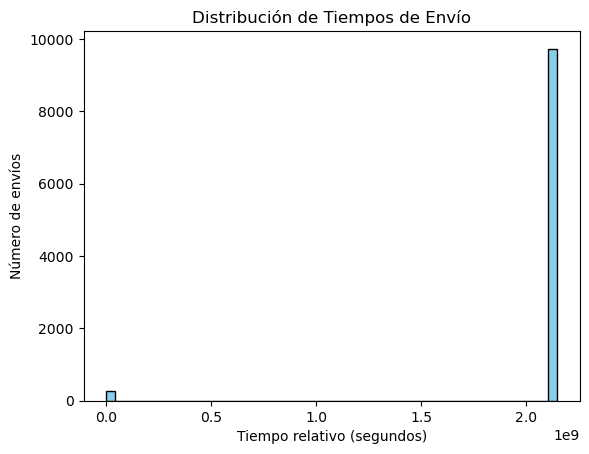

In [85]:
import matplotlib.pyplot as plt

plt.hist(df_clean["relative_time_n"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribución de Tiempos de Envío")
plt.xlabel("Tiempo relativo (segundos)")
plt.ylabel("Número de envíos")
plt.show()


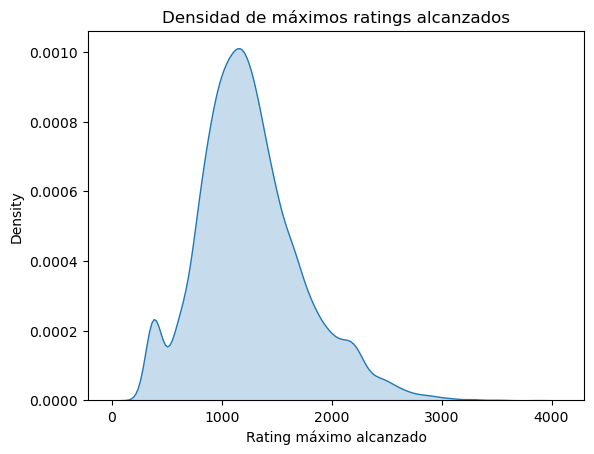

In [87]:
import seaborn as sns

sns.kdeplot(df_rating["newRating"], fill=True)
plt.title("Densidad de máximos ratings alcanzados")
plt.xlabel("Rating máximo alcanzado")
plt.show()


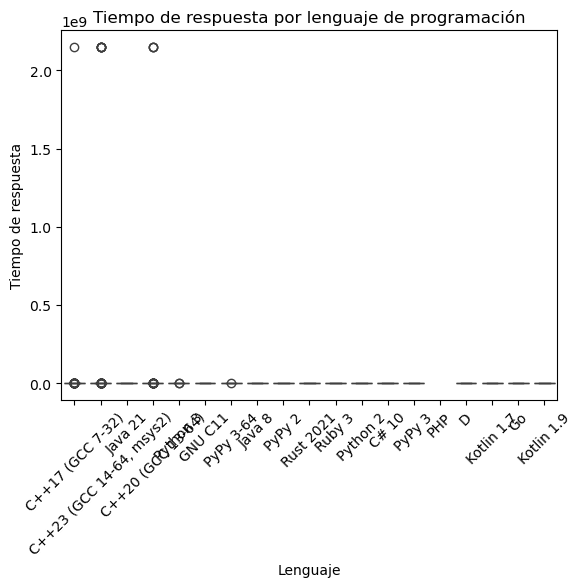

In [89]:
sns.boxplot(x="programmingLanguage", y="time_to_answer_n", data=df_clean)
plt.xticks(rotation=45)
plt.title("Tiempo de respuesta por lenguaje de programación")
plt.xlabel("Lenguaje")
plt.ylabel("Tiempo de respuesta")
plt.show()


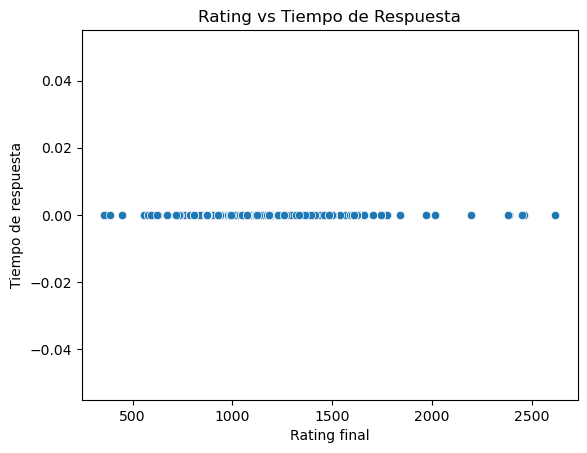

In [91]:
df_merge = pd.merge(df_clean, df_rating, on="handle", how="inner")

sns.scatterplot(x="newRating", y="time_to_answer_n", data=df_merge)
plt.title("Rating vs Tiempo de Respuesta")
plt.xlabel("Rating final")
plt.ylabel("Tiempo de respuesta")
plt.show()


                            OLS Regression Results                            
Dep. Variable:        rating_achieved   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     2768.
Date:                Wed, 16 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:32:27   Log-Likelihood:                -90210.
No. Observations:               14757   AIC:                         1.804e+05
Df Residuals:                   14755   BIC:                         1.804e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        170.0528      2.573     66.081      0.0

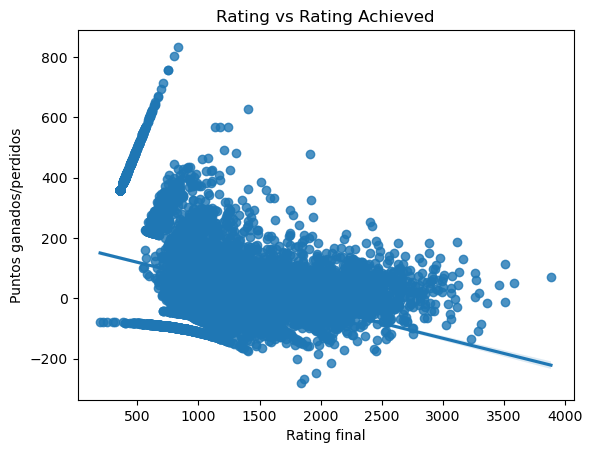

In [93]:
import statsmodels.api as sm

X = df_rating["newRating"]
y = df_rating["rating_achieved"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

# Gráfico con línea de regresión
sns.regplot(x="newRating", y="rating_achieved", data=df_rating)
plt.title("Rating vs Rating Achieved")
plt.xlabel("Rating final")
plt.ylabel("Puntos ganados/perdidos")
plt.show()
